# Confidence Interval Analysis

## Objective
Calculate confidence intervals for population parameters using sample data and interpret the uncertainty around estimates.

## Dataset
California Housing Dataset

## Tools Used
- Python
- NumPy
- Pandas
- SciPy
- Matplotlib
- Scikit-learn
- Jupyter Notebook / Google Colab

## Confidence Levels
- 90%
- 95%
- 99%

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.datasets import fetch_california_housing

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load California Housing dataset

housing = fetch_california_housing(as_frame=True)

df = housing.frame

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (20640, 9)


In [3]:
# Display first five rows

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# Display column names

print("Columns:")
print(df.columns.tolist())

Columns:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


In [5]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
# Descriptive statistics

df.describe()# Descriptive statistics

df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
# Check missing values

print("Missing values:")
print(df.isnull().sum())

Missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [8]:
# Variables selected for confidence interval analysis

variables = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "Population"
]

df[variables].describe()

,MedInc,HouseAge,AveRooms,Population
count,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1425.476744
std,1.899822,12.585558,2.474173,1132.462122
min,0.499900,1.000000,0.846154,3.000000
25%,2.563400,18.000000,4.440716,787.000000
50%,3.534800,29.000000,5.229129,1166.000000
75%,4.743250,37.000000,6.052381,1725.000000
max,15.000100,52.000000,141.909091,35682.000000


In [9]:
def calculate_confidence_interval(data, confidence_level):
    """
    Calculate confidence interval for a population mean
    using the t-distribution.
    """

    data = np.array(data)

    n = len(data)
    mean = np.mean(data)
    std = np.std(data, ddof=1)

    standard_error = std / np.sqrt(n)

    alpha = 1 - confidence_level

    t_critical = stats.t.ppf(
        1 - alpha / 2,
        df=n - 1
    )

    margin_of_error = t_critical * standard_error

    lower_bound = mean - margin_of_error
    upper_bound = mean + margin_of_error

    return mean, lower_bound, upper_bound, margin_of_error

In [10]:
mean, lower, upper, margin = calculate_confidence_interval(
    df["MedInc"],
    0.95
)

print("Mean:", mean)
print("Lower Bound:", lower)
print("Upper Bound:", upper)
print("Margin of Error:", margin)

Mean: 3.8706710029069766
Lower Bound: 3.844751207911283
Upper Bound: 3.8965907979026704
Margin of Error: 0.02591979499569386


In [11]:
confidence_levels = [0.90, 0.95, 0.99]

results = []

for variable in variables:

    data = df[variable].dropna()

    for confidence in confidence_levels:

        mean, lower, upper, margin = calculate_confidence_interval(
            data,
            confidence
        )

        results.append({
            "Variable": variable,
            "Confidence Level": f"{int(confidence * 100)}%",
            "Mean": mean,
            "Lower Bound": lower,
            "Upper Bound": upper,
            "Margin of Error": margin
        })

results_df = pd.DataFrame(results)

results_df

,Variable,Confidence Level,Mean,Lower Bound,Upper Bound,Margin of Error
0,MedInc,90%,3.870671,3.848919,3.892423,0.021752
1,MedInc,95%,3.870671,3.844751,3.896591,0.025920
2,MedInc,99%,3.870671,3.836605,3.904737,0.034066
3,HouseAge,90%,28.639486,28.495386,28.783587,0.144100
4,HouseAge,95%,28.639486,28.467778,28.811195,0.171708
5,HouseAge,99%,28.639486,28.413816,28.865157,0.225671
6,AveRooms,90%,5.429000,5.400671,5.457328,0.028328
7,AveRooms,95%,5.429000,5.395244,5.462756,0.033756
8,AveRooms,99%,5.429000,5.384636,5.473364,0.044364
9,Population,90%,1425.476744,1412.510458,1438.443030,12.966286


In [12]:
# Round numerical results

results_df.round(4)

,Variable,Confidence Level,Mean,Lower Bound,Upper Bound,Margin of Error
0,MedInc,90%,3.8707,3.8489,3.8924,0.0218
1,MedInc,95%,3.8707,3.8448,3.8966,0.0259
2,MedInc,99%,3.8707,3.8366,3.9047,0.0341
3,HouseAge,90%,28.6395,28.4954,28.7836,0.1441
4,HouseAge,95%,28.6395,28.4678,28.8112,0.1717
5,HouseAge,99%,28.6395,28.4138,28.8652,0.2257
6,AveRooms,90%,5.4290,5.4007,5.4573,0.0283
7,AveRooms,95%,5.4290,5.3952,5.4628,0.0338
8,AveRooms,99%,5.4290,5.3846,5.4734,0.0444
9,Population,90%,1425.4767,1412.5105,1438.4430,12.9663


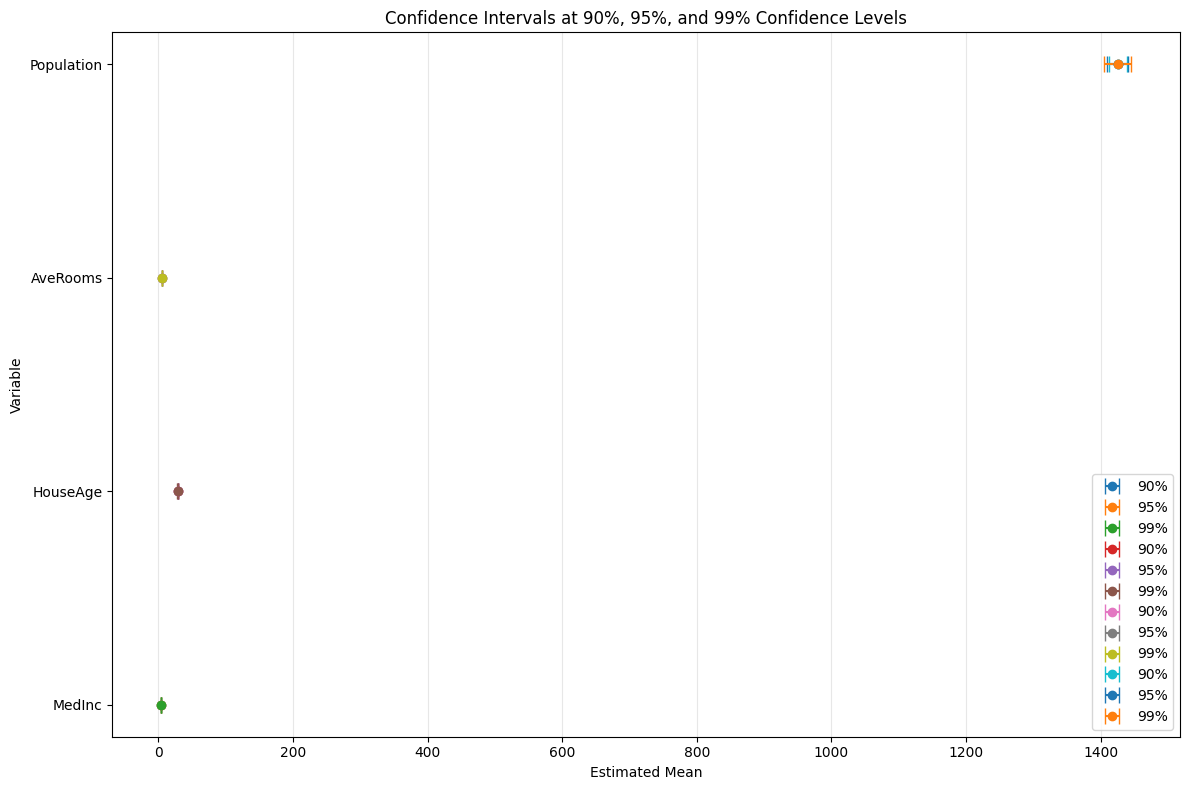

In [13]:
# Confidence interval visualization

plt.figure(figsize=(12, 8))

variables_plot = variables
y_positions = np.arange(len(variables_plot))

for i, variable in enumerate(variables_plot):

    variable_data = results_df[
        results_df["Variable"] == variable
    ]

    for _, row in variable_data.iterrows():

        plt.errorbar(
            row["Mean"],
            i,
            xerr=row["Margin of Error"],
            fmt='o',
            capsize=6,
            label=row["Confidence Level"]
        )

plt.yticks(y_positions, variables_plot)

plt.xlabel("Estimated Mean")
plt.ylabel("Variable")

plt.title(
    "Confidence Intervals at 90%, 95%, and 99% Confidence Levels"
)

plt.grid(axis="x", alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

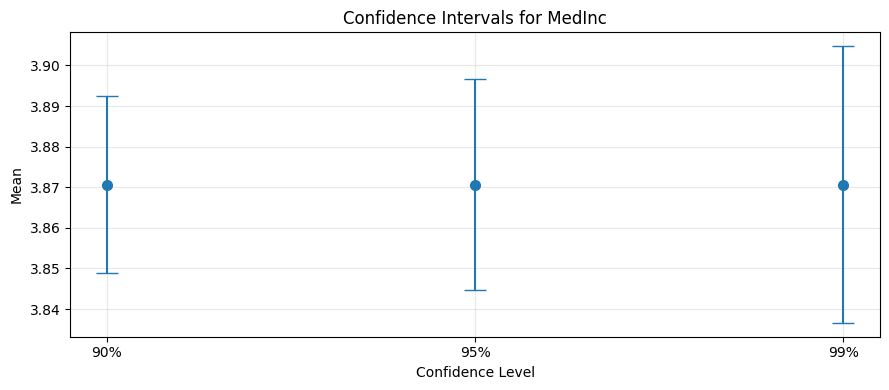

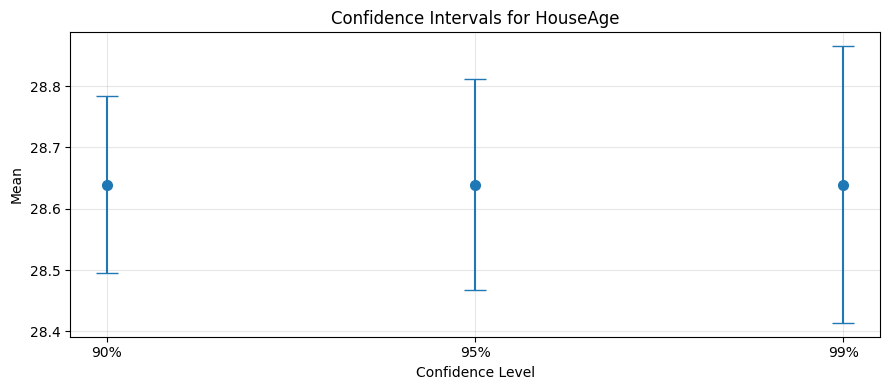

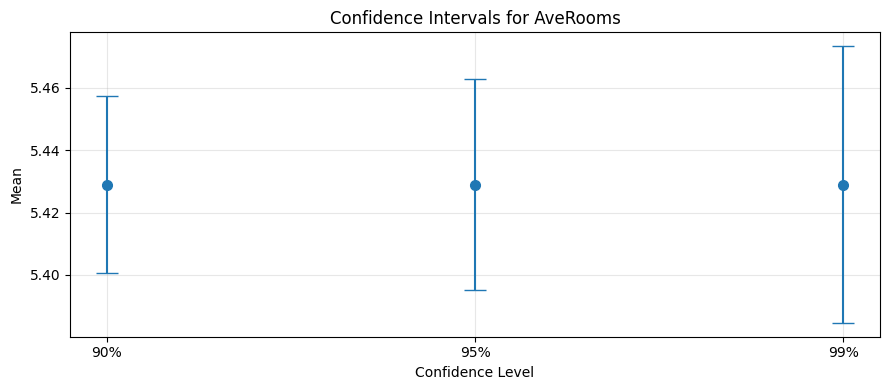

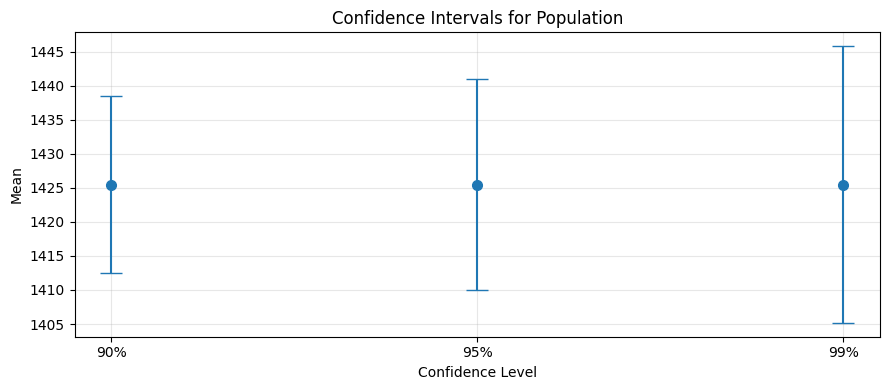

In [14]:
for variable in variables:

    subset = results_df[
        results_df["Variable"] == variable
    ]

    plt.figure(figsize=(9, 4))

    plt.errorbar(
        subset["Confidence Level"],
        subset["Mean"],
        yerr=subset["Margin of Error"],
        fmt='o',
        capsize=8,
        markersize=7
    )

    plt.title(
        f"Confidence Intervals for {variable}"
    )

    plt.xlabel("Confidence Level")
    plt.ylabel("Mean")

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [15]:
summary_table = results_df.copy()

summary_table["Mean"] = summary_table["Mean"].round(4)
summary_table["Lower Bound"] = summary_table["Lower Bound"].round(4)
summary_table["Upper Bound"] = summary_table["Upper Bound"].round(4)
summary_table["Margin of Error"] = summary_table["Margin of Error"].round(4)

summary_table

,Variable,Confidence Level,Mean,Lower Bound,Upper Bound,Margin of Error
0,MedInc,90%,3.8707,3.8489,3.8924,0.0218
1,MedInc,95%,3.8707,3.8448,3.8966,0.0259
2,MedInc,99%,3.8707,3.8366,3.9047,0.0341
3,HouseAge,90%,28.6395,28.4954,28.7836,0.1441
4,HouseAge,95%,28.6395,28.4678,28.8112,0.1717
5,HouseAge,99%,28.6395,28.4138,28.8652,0.2257
6,AveRooms,90%,5.4290,5.4007,5.4573,0.0283
7,AveRooms,95%,5.4290,5.3952,5.4628,0.0338
8,AveRooms,99%,5.4290,5.3846,5.4734,0.0444
9,Population,90%,1425.4767,1412.5105,1438.4430,12.9663


In [16]:
summary_table["Interval Width"] = (
    summary_table["Upper Bound"] -
    summary_table["Lower Bound"]
)

summary_table["Interval Width"] = summary_table[
    "Interval Width"
].round(4)

summary_table

,Variable,Confidence Level,Mean,Lower Bound,Upper Bound,Margin of Error,Interval Width
0,MedInc,90%,3.8707,3.8489,3.8924,0.0218,0.0435
1,MedInc,95%,3.8707,3.8448,3.8966,0.0259,0.0518
2,MedInc,99%,3.8707,3.8366,3.9047,0.0341,0.0681
3,HouseAge,90%,28.6395,28.4954,28.7836,0.1441,0.2882
4,HouseAge,95%,28.6395,28.4678,28.8112,0.1717,0.3434
5,HouseAge,99%,28.6395,28.4138,28.8652,0.2257,0.4514
6,AveRooms,90%,5.4290,5.4007,5.4573,0.0283,0.0566
7,AveRooms,95%,5.4290,5.3952,5.4628,0.0338,0.0676
8,AveRooms,99%,5.4290,5.3846,5.4734,0.0444,0.0888
9,Population,90%,1425.4767,1412.5105,1438.4430,12.9663,25.9325


In [17]:
for variable in variables:

    print(f"\n{variable}")

    temp = summary_table[
        summary_table["Variable"] == variable
    ]

    print(
        temp[
            [
                "Confidence Level",
                "Interval Width"
            ]
        ].to_string(index=False)
    )


MedInc
Confidence Level  Interval Width
             90%          0.0435
             95%          0.0518
             99%          0.0681

HouseAge
Confidence Level  Interval Width
             90%          0.2882
             95%          0.3434
             99%          0.4514

AveRooms
Confidence Level  Interval Width
             90%          0.0566
             95%          0.0676
             99%          0.0888

Population
Confidence Level  Interval Width
             90%         25.9325
             95%         30.9010
             99%         40.6121


## Interpretation

### MedInc

The confidence interval estimates the range in which the true population mean of median income is likely to lie.

The 90% confidence interval is narrower than the 95% interval, while the 99% interval is the widest. This demonstrates that higher confidence requires a wider interval.

### HouseAge

The confidence interval provides an estimated range for the population mean house age. Increasing the confidence level from 90% to 99% increases the width of the interval.

### AveRooms

The confidence intervals estimate the uncertainty surrounding the population mean number of rooms. The 99% confidence interval provides greater confidence but is wider than the 90% and 95% intervals.

### Population

The confidence interval estimates the uncertainty around the population mean. As the confidence level increases, the margin of error increases and therefore the interval becomes wider.

# Conclusion

This project demonstrated how confidence intervals can be used to estimate population parameters from sample data.

Confidence intervals were calculated for four statistics from the California Housing dataset:

1. Median Income (MedInc)
2. House Age (HouseAge)
3. Average Rooms (AveRooms)
4. Population

For each statistic, 90%, 95%, and 99% confidence intervals were calculated using the t-distribution.

The analysis demonstrated an important statistical principle:

**Higher confidence levels produce wider confidence intervals.**

The 90% confidence intervals were the narrowest, while the 99% confidence intervals were the widest. This occurs because greater confidence requires a larger range of plausible values.

The project also demonstrated how confidence intervals communicate uncertainty rather than providing a single point estimate.

Overall, confidence intervals are useful for understanding the reliability and uncertainty associated with estimates derived from sample data.

## Key Findings

- Confidence intervals provide a range of plausible values for population parameters.
- The sample mean acts as the point estimate.
- The t-distribution is used because the population standard deviation is unknown.
- 90% confidence intervals are narrower than 95% intervals.
- 99% confidence intervals are the widest.
- Increasing confidence increases the margin of error.
- A confidence interval communicates uncertainty more effectively than a point estimate alone.

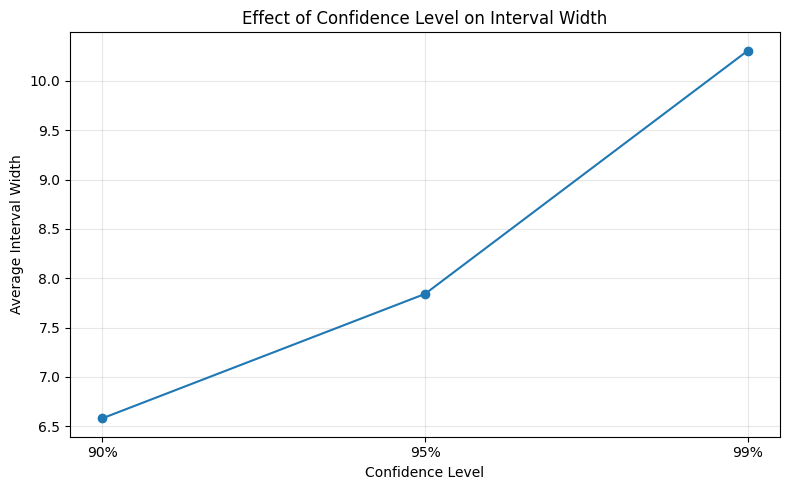

In [18]:
# Compare average interval widths by confidence level

width_comparison = (
    summary_table
    .groupby("Confidence Level")["Interval Width"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.plot(
    width_comparison.index,
    width_comparison.values,
    marker="o"
)

plt.title("Effect of Confidence Level on Interval Width")
plt.xlabel("Confidence Level")
plt.ylabel("Average Interval Width")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# Save confidence interval results

results_df.to_csv(
    "confidence_interval_results.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!
